Location on : "/content/drive/MyDrive/Deep Learning projects/Vision models/Img upscaler"

```
with tf.device('/GPU:0'):
    cnn.fit(...)
```



In [1]:
cd /content/drive/MyDrive/'Deep Learning projects'/'Vision models'/'Img upscaler'

/content/drive/MyDrive/Deep Learning projects/Vision models/Img upscaler


# Lib Imports

In [2]:
import tensorflow as tf
from tensorflow import keras

BATCH_SIZE = 8
IMG_SIZE = (256, 256)
SCALE = 2

train_hr = keras.utils.image_dataset_from_directory(
    "DS/train",
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_hr = keras.utils.image_dataset_from_directory(
    "DS/val",
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_hr = keras.utils.image_dataset_from_directory(
    "DS/test",
    labels=None,
    image_size=IMG_SIZE,
    batch_size=1,
    shuffle=False
)


Found 200 files.
Found 100 files.
Found 200 files.


In [3]:
def make_xy(hr):
    hr = tf.cast(hr, tf.float32) / 255.0   # Y (HR)

    lr = tf.image.resize(
        hr,
        (hr.shape[1] // SCALE, hr.shape[2] // SCALE),
        method="bicubic"
    )

    return lr, hr   # X , Y


In [4]:
train_ds = train_hr.map(make_xy, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_hr.map(make_xy,   num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_hr.map(make_xy)


In [5]:
for x, y in train_ds.take(1):
    print("X:", x.shape)   # (B, 128, 128, 3)
    print("Y:", y.shape)

X: (8, 128, 128, 3)
Y: (8, 256, 256, 3)


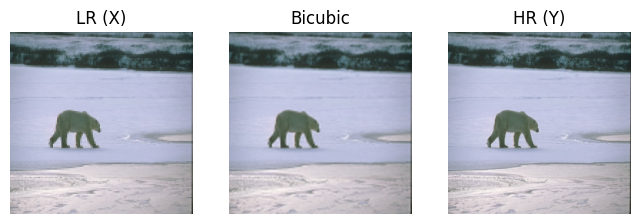

In [6]:
import matplotlib.pyplot as plt

for x, y in test_ds.take(1):
    plt.figure(figsize=(8,4))

    plt.subplot(1,3,1)
    plt.title("LR (X)")
    plt.imshow(x[0])
    plt.axis("off")

    # bicubic upsample for comparison
    bicubic = tf.image.resize(x[0], IMG_SIZE, method="bicubic")

    plt.subplot(1,3,2)
    plt.title("Bicubic")
    plt.imshow(bicubic)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("HR (Y)")
    plt.imshow(y[0])
    plt.axis("off")

    plt.show()


# Attention

In [12]:
from tensorflow.keras import layers

def attention_block(x):
    """
    Multiplicative attention
    """
    attn = layers.Conv2D(
        x.shape[-1], 1, padding="same", activation="sigmoid"
    )(x)
    return layers.Multiply()([x, attn])

# **Auto** - **Encoder**

In [13]:
from tensorflow.keras import Model, Input

def build_sr_autoencoder_2x():
    inp = Input(shape=(None, None, 3))  # LR input

    # -------- Encoder --------
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inp)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    # -------- Attention --------
    x = attention_block(x)

    # -------- Decoder: SINGLE 2x upscaling --------
    x = layers.UpSampling2D(size=(2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    out = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

    return Model(inp, out, name="SR_AutoEncoder_2x")


In [14]:
model = build_sr_autoencoder_2x()
model.compile(optimizer="adam", loss="mse")
model.summary()


Model: "SR_AutoEncoder_2x"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, None,      │      1,792 │ input_layer_1[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_7[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, None,      │     73,856 │ conv2d_8[0][0]    │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, None,      │    147,584 │ conv2d_9[0][0]    │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, None,      │     16,512 │ conv2d_10[0][0]   │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, None,      │          0 │ conv2d_10[0][0],  │
│ (Multiply)          │ None, 128)        │            │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, None,      │          0 │ multiply_1[0][0]  │
│ (UpSampling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, None,      │     73,792 │ up_sampling2d_2[… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, None,      │      1,731 │ conv2d_12[0][0]   │
│                     │ None, 3)          │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 352,195 (1.34 MB)

 Trainable params: 352,195 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
with tf.device('/GPU:0'):
  history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 452ms/step - loss: 0.0610 - val_loss: 0.0270
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - loss: 0.0192 - val_loss: 0.0090
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - loss: 0.0078 - val_loss: 0.0062
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - loss: 0.0057 - val_loss: 0.0051
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - loss: 0.0049 - val_loss: 0.0044
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - loss: 0.0031 - val_loss: 0.0036
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


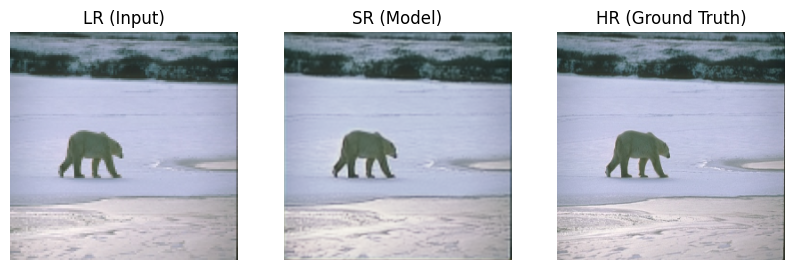

In [16]:
import matplotlib.pyplot as plt
import tensorflow as tf

for x, y in test_ds.take(1):
    sr = model.predict(x)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.title("LR (Input)")
    plt.imshow(x[0])
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("SR (Model)")
    plt.imshow(sr[0])
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("HR (Ground Truth)")
    plt.imshow(y[0])
    plt.axis("off")

    plt.show()
